# Image Model Testing Notebook
This notebook allows you to:
- Upload a trained image model (.h5 or .keras)
- Upload one image for testing
- Preprocess and predict the output class

In [2]:
# Step 2: Upload your trained image model file
from google.colab import files
import os

print('Please upload your trained image model file (e.g., image_model.h5)')
uploaded = files.upload()

model_path = list(uploaded.keys())[0]
print('Model uploaded:', model_path)

Please upload your trained image model file (e.g., image_model.h5)


Saving image_classification_model.h5 to image_classification_model.h5
Model uploaded: image_classification_model.h5


In [3]:
# Step 3: Load the image model
import tensorflow as tf

try:
    image_model = tf.keras.models.load_model(model_path)
    print('Model loaded successfully!')
except Exception as e:
    print('Error loading model:', e)

Model loaded successfully!


In [17]:
# Step 4: Upload an image for prediction
print('Upload one test image for prediction:')
uploaded_img = files.upload()

img_path = list(uploaded_img.keys())[0]
print('Image uploaded:', img_path)

Upload one test image for prediction:


Saving Screenshot 2025-11-11 001043.png to Screenshot 2025-11-11 001043.png
Image uploaded: Screenshot 2025-11-11 001043.png


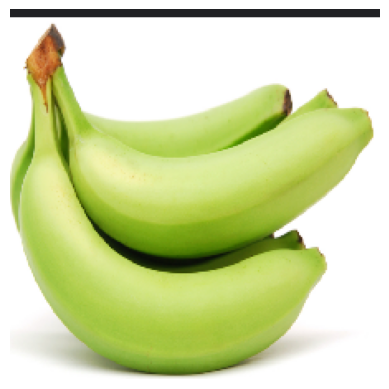

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Predicted class: 3
Raw output: [[1.6925074e-04 8.4736897e-04 2.6355595e-03 9.9634784e-01]]


In [18]:
# Step 5: Preprocess and predict
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load and show image
img = image.load_img(img_path, target_size=(224, 224))  # Change size if needed
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array and normalize
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = image_model.predict(img_array)
pred_class = np.argmax(pred, axis=1)[0]
print('Predicted class:', pred_class)
print('Raw output:', pred)